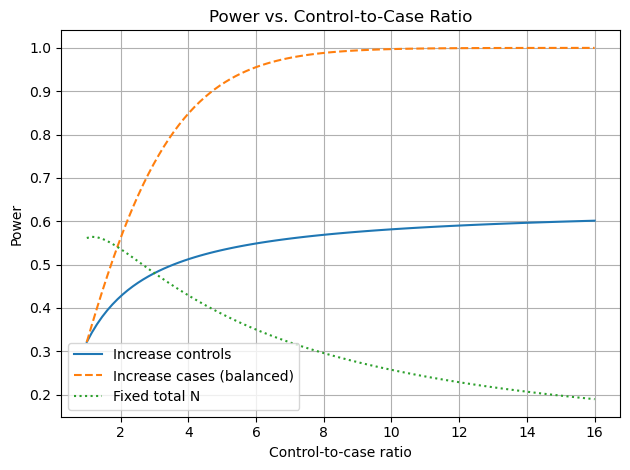

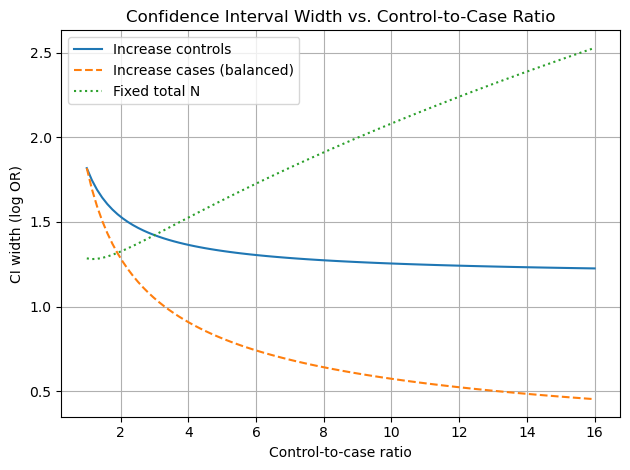

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# -----------------------------
# Parameters
# -----------------------------
OR = 2.0
p0 = 0.2
alpha = 0.05

n_cases_base = 50
n_total_fixed = 200

max_ratio = 16
n_points = 100

zcrit = norm.ppf(1 - alpha / 2)

# -----------------------------
# Helper functions
# -----------------------------
def p_case(OR, p0):
    return (OR * p0) / (1 - p0 + OR * p0)

def var_log_or(n1, n0):
    p1 = p_case(OR, p0)
    return (
        1 / (n1 * p1) +
        1 / (n1 * (1 - p1)) +
        1 / (n0 * p0) +
        1 / (n0 * (1 - p0))
    )

def power(n1, n0):
    v = var_log_or(n1, n0)
    z = np.log(OR) / np.sqrt(v)
    return norm.cdf(z - zcrit) + norm.cdf(-z - zcrit)

def ci_width(n1, n0):
    v = var_log_or(n1, n0)
    return 2 * zcrit * np.sqrt(v)

# -----------------------------
# Generate data
# -----------------------------
ratios = np.linspace(1, max_ratio, n_points)

power_controls = []
power_balanced = []
power_fixedN = []

ci_controls = []
ci_balanced = []
ci_fixedN = []

for r in ratios:
    # 1. Increasing controls
    n1 = n_cases_base
    n0 = n_cases_base * r
    power_controls.append(power(n1, n0))
    ci_controls.append(ci_width(n1, n0))

    # 2. Increasing cases (balanced)
    n1 = n_cases_base * r
    n0 = n1
    power_balanced.append(power(n1, n0))
    ci_balanced.append(ci_width(n1, n0))

    # 3. Fixed total N
    n1 = n_total_fixed / (1 + r)
    n0 = n_total_fixed * r / (1 + r)
    power_fixedN.append(power(n1, n0))
    ci_fixedN.append(ci_width(n1, n0))

# -----------------------------
# Plot 1: Power
# -----------------------------
plt.figure()

plt.plot(ratios, power_controls, label="Increase controls")
plt.plot(ratios, power_balanced, linestyle="--", label="Increase cases (balanced)")
plt.plot(ratios, power_fixedN, linestyle=":", label="Fixed total N")

plt.xlabel("Control-to-case ratio")
plt.ylabel("Power")
plt.title("Power vs. Control-to-Case Ratio")
plt.legend()
plt.grid()

plt.tight_layout()
plt.savefig("power_plot.png", dpi=300)

# -----------------------------
# Plot 2: CI Width
# -----------------------------
plt.figure()

plt.plot(ratios, ci_controls, label="Increase controls")
plt.plot(ratios, ci_balanced, linestyle="--", label="Increase cases (balanced)")
plt.plot(ratios, ci_fixedN, linestyle=":", label="Fixed total N")

plt.xlabel("Control-to-case ratio")
plt.ylabel("CI width (log OR)")
plt.title("Confidence Interval Width vs. Control-to-Case Ratio")
plt.legend()
plt.grid()

plt.tight_layout()
plt.savefig("ci_width_plot.png", dpi=300)

plt.show()